# 05 · Testing the DAF-MIT AIA dataset (Zenodo 12723700)
Record 12723700 adds flights beyond the challenge set (4271804): **Flt1006** (the dedicated calibration flight), **Flt1007** (navigation), and 2021 flights (Flt20xx, XYZ21 format). This notebook downloads a few of them and validates that they load and are navigable.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## Download flights unique to 12723700

In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from magnavlab import data
from magnavlab.io import load_flight, load_map, segment_indices
data.fetch_flight('Flt1006')   # calibration flight
data.fetch_flight('Flt1007')   # navigation flight
data.fetch_flight('Flt2005')   # 2021 flight (XYZ21 format)
data.fetch_maps(['Eastern_395'])

  Flt1006: already present, skip
  Flt1007: already present, skip
  Flt2005: already present, skip
  maps: already present, skip


['data/maps/Eastern_395.h5']

## Structural validation — do all flights load with the required fields?
Covers both the 2020 (XYZ20) and 2021 (XYZ21) formats.

In [3]:
need = ['tt','lat','lon','alt','mag_1_c','mag_4_uc','igrf','diurnal']
for name in ['Flt1006','Flt1007','Flt2005']:
    fl = load_flight(f'data/{name}_train.h5')
    miss = [k for k in need if not fl.has(k)]
    try:
        fl.flux(); flux_ok = True
    except Exception:
        flux_ok = False
    print(f"{name}: {fl.n:7d} samples @ {1/fl.dt:.0f} Hz, ~{fl.n*fl.dt/60:.0f} min, "
          f"flux={flux_ok}, missing={miss or 'none'}")

Flt1006:  108318 samples @ 10 Hz, ~181 min, flux=True, missing=none


Flt1007:  114506 samples @ 10 Hz, ~191 min, flux=True, missing=none
Flt2005:    6361 samples @ 10 Hz, ~11 min, flux=True, missing=none


## Flt1006 — the dedicated calibration flight
`data.CAL_SEGMENTS['Flt1006']` holds the pitch/roll/yaw maneuver windows used to fit the Tolles-Lawson coefficients. The attitude excursions are what make the aircraft-field terms observable.

9 calibration segments, 40986 samples total


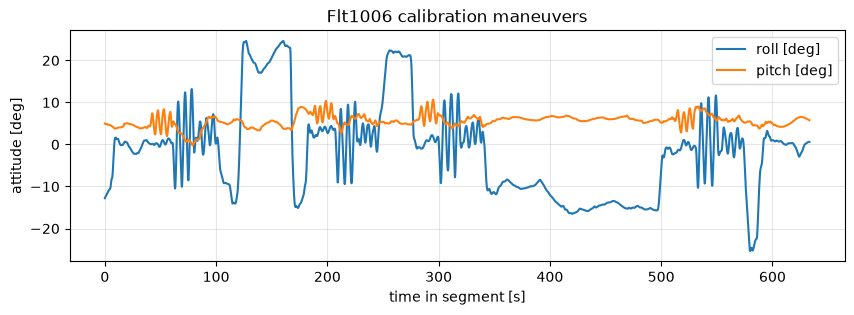

In [4]:
cal = load_flight('data/Flt1006_train.h5')
segs = data.CAL_SEGMENTS['Flt1006']
total = sum(segment_indices(cal, a, b).size for a, b in segs)
print(f'{len(segs)} calibration segments, {total} samples total')
a, b = segs[1]; m = segment_indices(cal, a, b)
t = cal.get('tt')[m] - cal.get('tt')[m][0]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, cal.get('roll')[m], label='roll [deg]')
ax.plot(t, cal.get('pitch')[m], label='pitch [deg]')
ax.set_xlabel('time in segment [s]'); ax.set_ylabel('attitude [deg]')
ax.set_title('Flt1006 calibration maneuvers'); ax.legend(); ax.grid(alpha=0.3);

## Navigability — measured field vs map, and the effect of altitude
A usable measurement correlates with the anomaly map. The Eastern_395 map is at 395 m, so flying near that altitude matches best. We compare an altitude-matched line (Flt1006 1006.08, ~400 m) with a higher one (Flt1007 1007.02, ~800 m).

Flt1006 Flt1006_1006.08: alt~432 m, corr(meas,map)=0.991
Flt1007 Flt1007_1007.02: alt~833 m, corr(meas,map)=0.954


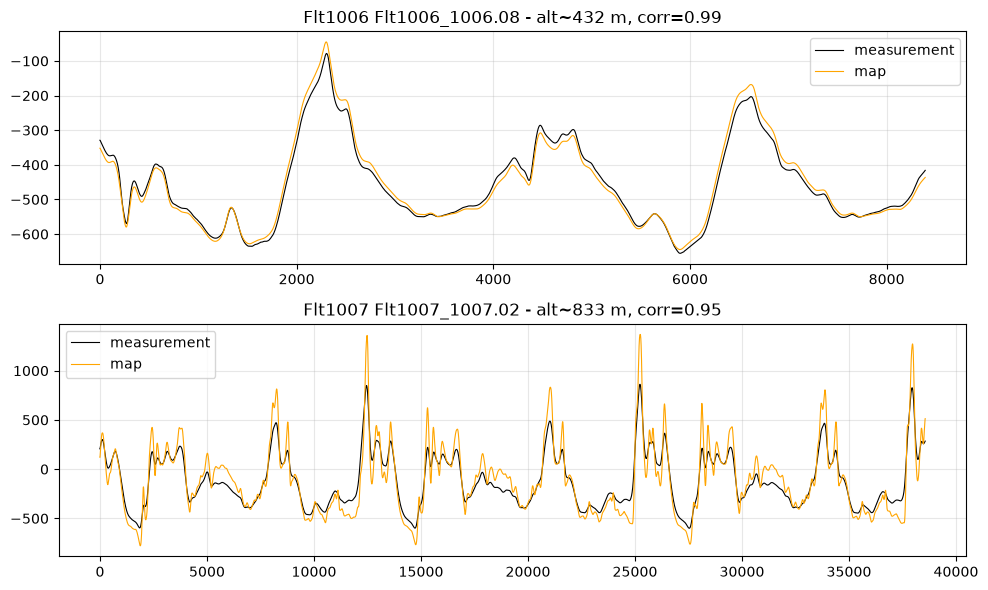

In [5]:
mag_map = load_map('data/maps/Eastern_395.h5')
def profile(name, tstart, tend):
    fl = load_flight(f'data/{name}_train.h5')
    sl = segment_indices(fl, tstart, tend)
    lat = np.radians(fl.get('lat')[sl]); lon = np.radians(fl.get('lon')[sl])
    z = fl.get('mag_1_c')[sl] - fl.get('diurnal')[sl]
    mv = mag_map.value(lat, lon); ok = np.isfinite(mv)
    z = z - np.median(z[ok] - mv[ok])
    return z, mv, fl.get('alt')[sl].mean(), np.corrcoef(z[ok], mv[ok])[0, 1]

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
for i, (name, key) in enumerate([('Flt1006','Flt1006_1006.08'),('Flt1007','Flt1007_1007.02')]):
    w = data.NAV_WINDOWS[key]
    z, mv, alt, c = profile(name, w['tstart'], w['tend'])
    print(f"{name} {key}: alt~{alt:.0f} m, corr(meas,map)={c:.3f}")
    ax[i].plot(z, 'k-', lw=0.8, label='measurement')
    ax[i].plot(mv, color='orange', lw=0.8, label='map')
    ax[i].set_title(f'{name} {key} - alt~{alt:.0f} m, corr={c:.2f}')
    ax[i].legend(); ax[i].grid(alpha=0.3)
fig.tight_layout();

Higher-altitude lines correlate less with the low-altitude map (the crustal field looks low-pass filtered with altitude) — the expected physics, and a reminder to match flight and map altitude (or upward-continue the map). Record 12723700 is fully supported, including the 2021 XYZ21 flights.